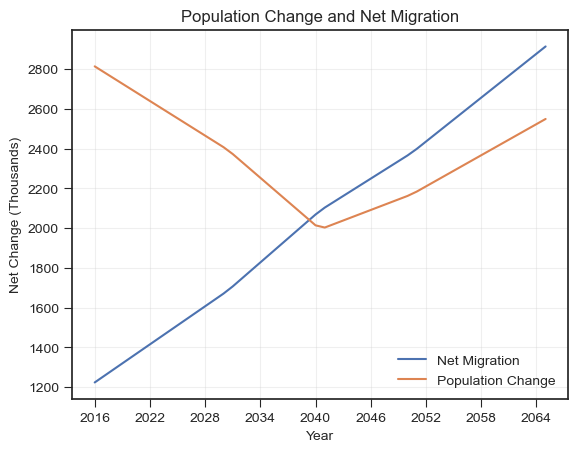

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import re
from scipy.optimize import curve_fit

plt.style.use('seaborn-v0_8-ticks')
sns.set_palette("deep")

gen = pd.read_csv("population_by_generation_1965-2060.csv")
race = pd.read_csv("population_with_without_immigration_2015-2060.csv")
intl = pd.read_csv("intl_student_enrollment_data.csv")

#Fix year format
intl["Year"] = [re.match(r"^\d{4}", year).group() for year in intl["Year"]]

#Migration growth
race = race.set_index("Year").reindex(range(race["Year"].min(), race["Year"].max() + 1))
race = race.interpolate(method="polynomial", order=2).reset_index()
race["Net Migration"] = race["Total Population (thousands)"] - race["Total (no 2015-2065 immigration) (thousands)"]
race["Migration per year"] = race["Net Migration"].diff()
race["Pop Change"] = race["Total Population (thousands)"].diff()
race["Migration-driven growth"] = race["Migration per year"] / race["Pop Change"] * 100




fig, ax = plt.subplots()
ax.plot(race["Year"], race["Migration per year"], label="Net Migration")
ax.plot(race["Year"], race["Pop Change"], label="Population Change")
ax.set_xlabel('Year')
ax.set_ylabel('Net Change (Thousands)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.title("Population Change and Net Migration")
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))  # Max 5 ticks on x-axis
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=10))  # Max 5 ticks on y-axis
plt.show()

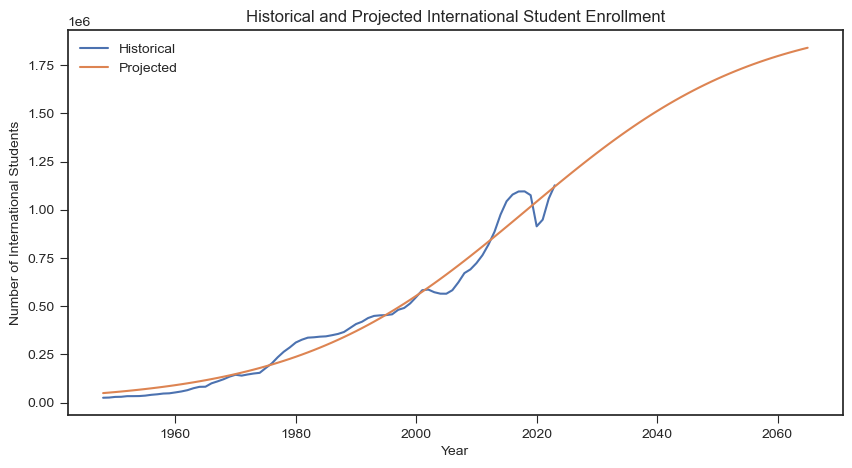

In [2]:
# Extract years and student numbers
X = intl["Year"].values
y = intl["Total Int'l Students"].values

# Define the logistic function
def logistic(t, L, k, t0):
    return L / (1 + np.exp(-k * (t - t0)))

# Initial guesses for parameters
L_guess = max(y) * 1.5  # Assume max capacity is 1.5 times the highest historical value
k_guess = 0.1  # Initial guess for growth rate
t0_guess = 2005  # Assume saturation starts around year 2000

# Fit the logistic model to historical data
popt, _ = curve_fit(logistic, X, y, p0=[L_guess, k_guess, t0_guess])

# Extract optimized parameters
L_opt, k_opt, t0_opt = popt

# Generate future year values (2024-2060)
future_years = np.arange(1948, 2066)

# Predict future international student numbers
future_students = logistic(future_years, L_opt, k_opt, t0_opt)

df_future_students = pd.DataFrame({
    "Year": future_years, 
    "Projected Int'l Students": future_students  # Changed column name to distinguish from historical data
})

# Plot historical vs. projected data
plt.figure(figsize=(10,5))
plt.plot(intl["Year"].astype("int"), intl["Total Int'l Students"], label="Historical")
plt.plot(df_future_students["Year"].astype("int"), df_future_students["Projected Int'l Students"], label="Projected")
plt.xlabel("Year")
plt.ylabel("Number of International Students")
plt.legend()
plt.title("Historical and Projected International Student Enrollment")
plt.show()



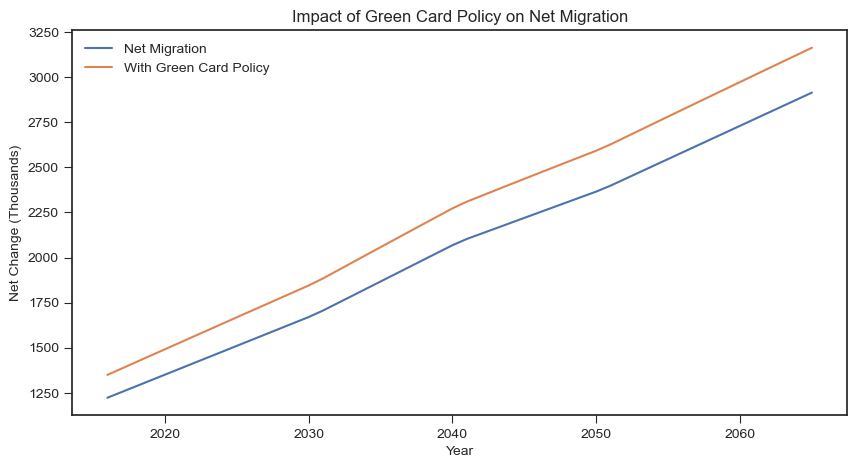

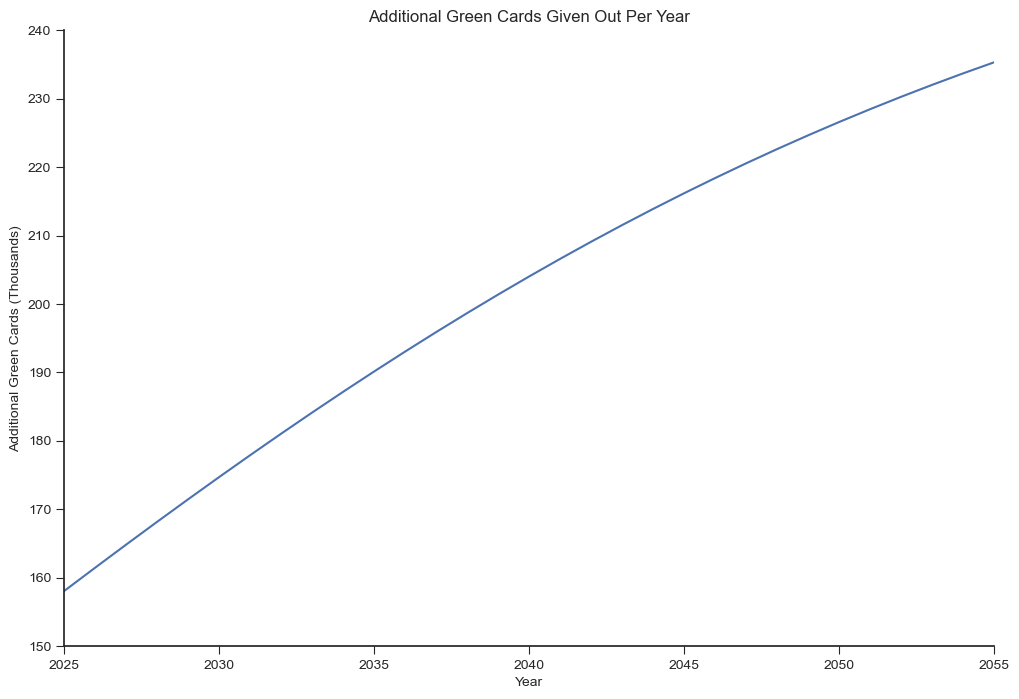

In [3]:
graduation_rate = 0.9
retention_rate = 0.6
school_years = 4

race['Year'] = race['Year'].astype(int)
df_future_students['Year'] = df_future_students['Year'].astype(int)

# Merge the migration data with projected students
merged = race.merge(
    df_future_students[['Year', "Projected Int'l Students"]],
    on='Year',
    how='left'
)

# Fill any missing values with 0 (for years before projections exist)
merged["Projected Int'l Students"] = merged["Projected Int'l Students"].fillna(0)

# Calculate the combined effect using vectorized operations
merged['Green Card Effect'] = merged['Migration per year'] + merged["Projected Int'l Students"] / 1000 * graduation_rate * retention_rate / school_years

plt.figure(figsize=(10,5))
plt.plot(merged["Year"], merged["Migration per year"], label="Net Migration")
plt.plot(merged["Year"], merged["Green Card Effect"], label="With Green Card Policy")
plt.xlabel('Year')
plt.ylabel('Net Change (Thousands)')
plt.legend()
plt.title("Impact of Green Card Policy on Net Migration")
plt.show()

merged['Green Card Difference'] = merged['Green Card Effect'] - merged['Migration per year']
plt.figure(figsize = (12,8))
plt.plot(merged["Year"], merged["Green Card Difference"])
plt.xlabel('Year')
plt.ylabel('Additional Green Cards (Thousands)')
plt.title("Additional Green Cards Given Out Per Year")
plt.xlim(2025,2055)
plt.ylim(150,240)
sns.despine()
plt.ticklabel_format(style= None)
plt.savefig('h1b_visas_given')
plt.show()


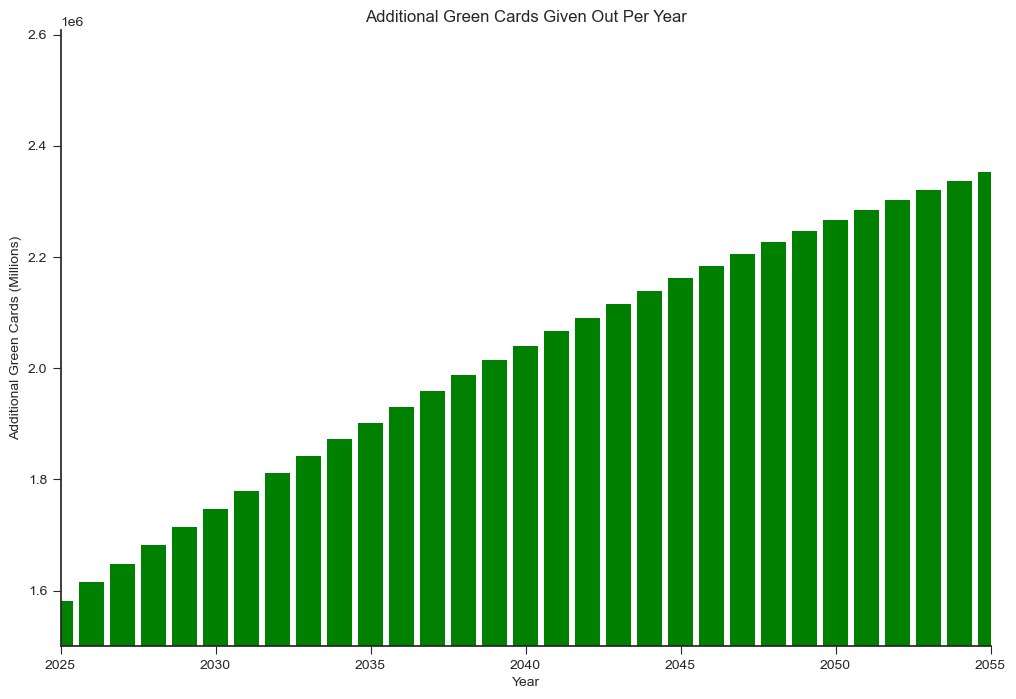

In [ ]:
#Fee Revenue
plt.figure(figsize = (12,8))
plt.bar(merged["Year"], merged["Green Card Difference"] * 10000, color = 'green')
plt.xlabel('Year')
plt.ylabel('Green Card Fees (Millions)')
plt.title("Green Card Fees Per Year")
plt.xlim(2025,2055)

sns.despine()
plt.ticklabel_format(style= None)

plt.ylim(bottom = 1500000)
plt.savefig('h1b_visas_fees')
plt.show()

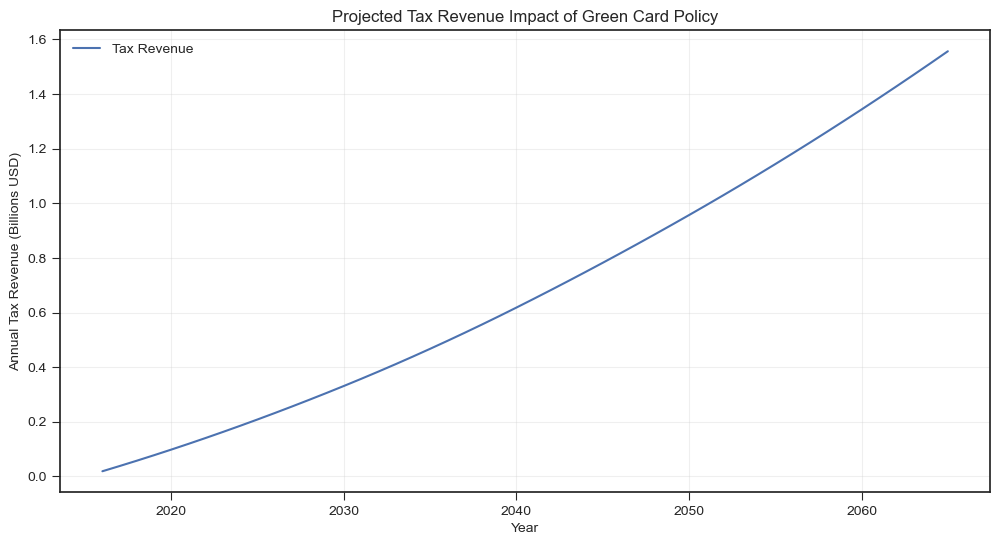

In [5]:
# Calculate cumulative additional migrants from policy
merged['Cumulative_Green_Card_Additions'] = merged['Green Card Effect'].cumsum()

# Assume 85% labor force participation and $65k average salary
labor_participation = 0.85
avg_salary = 65_000  # USD
effective_tax_rate = 0.25  # Income + payroll taxes

merged['Annual_Tax_Revenue'] = (
    merged['Cumulative_Green_Card_Additions'] 
    * labor_participation 
    * avg_salary 
    * effective_tax_rate
)

# Plot results
plt.figure(figsize=(12,6))
plt.plot(merged['Year'], merged['Annual_Tax_Revenue']/1e9, label='Tax Revenue')
plt.xlabel('Year')
plt.ylabel('Annual Tax Revenue (Billions USD)')
plt.title('Projected Tax Revenue Impact of Green Card Policy')
plt.grid(True, alpha=0.3)
plt.legend()

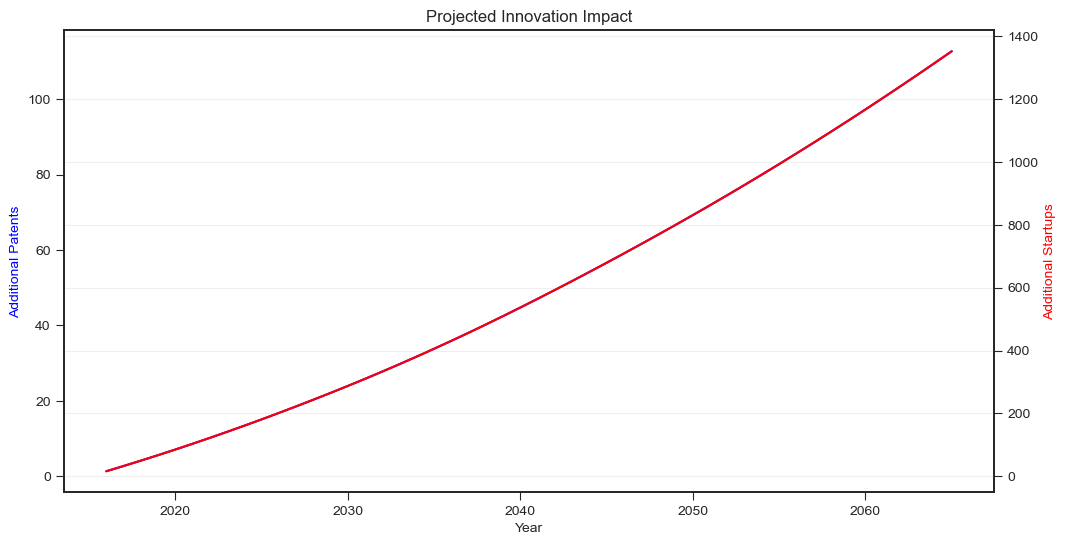

In [6]:
# Assume 10% become innovators with economic impact
stem_ratio = 0.4  # 40% of international students in STEM
patent_rate = 2.5  # Patents per 1000 STEM workers
startup_rate = 0.03  # 3% found startups

merged['Annual_Patents'] = (
    merged['Cumulative_Green_Card_Additions']
    * stem_ratio
    * patent_rate / 1000
)

merged['Annual_Startups'] = (
    merged['Cumulative_Green_Card_Additions']
    * stem_ratio
    * startup_rate
)

# Visualize innovation impact
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(merged['Year'], merged['Annual_Patents'], 'b-', label='Patents')
ax1.set_xlabel('Year')
ax1.set_ylabel('Additional Patents', color='b')

ax2 = ax1.twinx()
ax2.plot(merged['Year'], merged['Annual_Startups'], 'r-', label='Startups')
ax2.set_ylabel('Additional Startups', color='r')
plt.title('Projected Innovation Impact')
plt.grid(True, alpha=0.3)
plt.show()

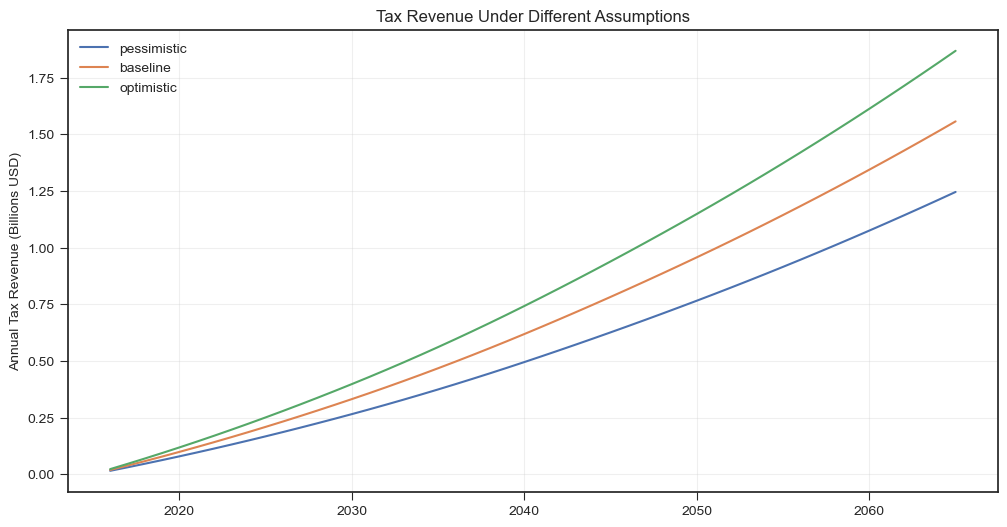

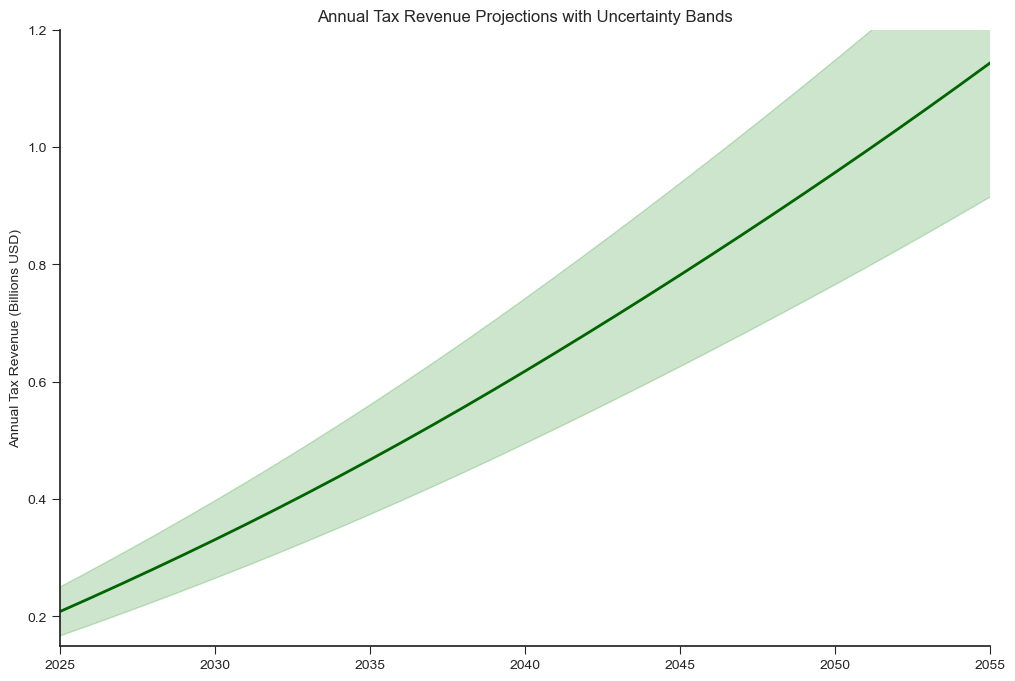

In [7]:
# Create parameter grid
scenarios = {
    'pessimistic': {'tax_rate': 0.20, 'stem_ratio': 0.3},
    'baseline': {'tax_rate': 0.25, 'stem_ratio': 0.4},
    'optimistic': {'tax_rate': 0.30, 'stem_ratio': 0.5}
}

# Compare outcomes
for scenario, params in scenarios.items():
    merged[f'Tax_Rev_{scenario}'] = (
        merged['Cumulative_Green_Card_Additions']
        * labor_participation
        * avg_salary
        * params['tax_rate']
    )
    
plt.figure(figsize=(12,6))
for scenario in scenarios:
    plt.plot(merged['Year'], merged[f'Tax_Rev_{scenario}']/1e9, label=scenario)
plt.title('Tax Revenue Under Different Assumptions')
plt.ylabel('Annual Tax Revenue (Billions USD)')
plt.grid(alpha=0.3)
plt.legend()

# Calculate confidence intervals
merged['Tax_Lower'] = merged['Annual_Tax_Revenue'] * 0.8
merged['Tax_Upper'] = merged['Annual_Tax_Revenue'] * 1.2

plt.figure(figsize=(12,8))
plt.fill_between(merged['Year'], merged['Tax_Lower']/1e9, merged['Tax_Upper']/1e9,
                 color='green', alpha=0.2)
plt.plot(merged['Year'], merged['Annual_Tax_Revenue']/1e9, 
         color='darkgreen', lw=2)
plt.title('Annual Tax Revenue Projections with Uncertainty Bands')
plt.xlim(2025,2055)
plt.ylim(0.15,1.2)
sns.despine()
plt.ylabel('Annual Tax Revenue (Billions USD)')
plt.savefig('h1b_tax_revenue')

In [8]:
def print_policy_impact(df, target_year=2055):
    baseline = df[df['Year'] == target_year]
    print(f"Projected 2055 Impact:")
    print(f"• Cumulative Additions: {baseline['Cumulative_Green_Card_Additions'].values[0]:,.0f} workers")
    print(f"• Annual Tax Revenue: ${baseline['Annual_Tax_Revenue'].values[0]/1e9:,.1f}B")
    print(f"• Lifetime Patents: {baseline['Annual_Patents'].values[0]:,.0f} per year")
    print(f"• New Startups: {baseline['Annual_Startups'].values[0]:,.0f} per year")

print_policy_impact(merged)

Projected 2055 Impact:
• Cumulative Additions: 82,792 workers
• Annual Tax Revenue: $1.1B
• Lifetime Patents: 83 per year
• New Startups: 994 per year
